# Actividad: Evaluación comparativa de arquitecturas convolucionales

Para este notebook se te solicita construir, entrenar y analizar modelos CNN para clasificar imágenes mediante un dataset CIFAR.

**Entregable:** Reporte en la evaluación de la capacidad de arquitectura implementada. Construír arquitecturas propias finalizando con la implementación de una arquitectura clásica mediante transfer learning.


## Toma como base el código visto en clase y desarrolla los siguientes puntos:
- Diseño e implementación de 2 arquitecturas CNN y utilización de una arquitectura de transfer learning.

- Buen uso de data augmentation y regularización.

- Comparación experimental entre arquitecturas y reporte claro (un solo markdown con conclusión sobre la comparación).





In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
# (seleccióna la arquitectura que desees, puedes buscar otras) VGG16, ResNet50, MobileNetV2


Matplotlib is building the font cache; this may take a moment.


In [3]:
#1. Cargar dataset

# Cargar dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalizar datos
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [4]:
#2. Data Augmentation

data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1)
])

## Definiciones de modelos

In [5]:
# Recuerda aquí solo generar las arquitecturas, cada capa así como sus neuronas.
#3. Arquitectura CNN 1 (simple)

#Primera arquitectura básica.

def build_cnn_model_1():

    model = keras.Sequential([
        data_augmentation,

        keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        keras.layers.MaxPooling2D((2,2)),

        keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2,2)),

        keras.layers.Flatten(),

        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.5),

        keras.layers.Dense(10, activation='softmax')
    ])

    return model

In [6]:
#4. Arquitectura CNN 2 (más profunda)

#Esta  mejora la comparación.

def build_cnn_model_2():

    model = keras.Sequential([
        data_augmentation,

        keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2,2)),

        keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2,2)),

        keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2,2)),

        keras.layers.Flatten(),

        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dropout(0.5),

        keras.layers.Dense(10, activation='softmax')
    ])

    return model

In [7]:
#5. Transfer Learning (VGG16)

#Aquí usamos una arquitectura clásica preentrenada.

def build_transfer_model():

    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(32,32,3)
    )

    base_model.trainable = False

    model = keras.Sequential([
        data_augmentation,
        base_model,

        keras.layers.GlobalAveragePooling2D(),

        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.5),

        keras.layers.Dense(10, activation='softmax')
    ])

    return model

In [8]:
#6. Crear modelos

model1 = build_cnn_model_1()
model2 = build_cnn_model_2()
model3 = build_transfer_model()

C:\Users\debia\desktop\aprendizaje_profundo\arquitecturas_cnn\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 605s 10us/step


## Entrenamiento de modelos.

In [9]:
# Aquí agrega la compilación y entrenamiento de las arquitecturas generadas.

#7. Compilar modelos

for model in [model1, model2, model3]:

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

In [11]:
#8. Entrenamiento

#Para que no tarde demasiado:
history1 = model1.fit(
    x_train, y_train,
    epochs=4,
    batch_size=64,
    validation_data=(x_test, y_test)
)

history2 = model2.fit(
    x_train, y_train,
    epochs=4,
    batch_size=64,
    validation_data=(x_test, y_test)
)

history3 = model3.fit(
    x_train, y_train,
    epochs=4,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.5893 - loss: 1.1672 - val_accuracy: 0.6479 - val_loss: 1.0061
Epoch 2/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.5955 - loss: 1.1511 - val_accuracy: 0.6443 - val_loss: 1.0453
Epoch 3/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.5995 - loss: 1.1429 - val_accuracy: 0.6474 - val_loss: 1.0253
Epoch 4/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.6032 - loss: 1.1261 - val_accuracy: 0.6547 - val_loss: 1.0069
Epoch 1/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 104ms/step - accuracy: 0.6859 - loss: 0.9189 - val_accuracy: 0.7023 - val_loss: 0.8608
Epoch 2/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 102ms/step - accuracy: 0.6949 - loss: 0.8820 - val_accuracy: 0.6851 - val_loss: 0.9292
Epoch 3/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 104ms/step - accuracy: 0.7037 - loss: 0.8648 - val_accuracy: 0.7426 - val_loss: 0.7490
Epoch 4/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 104ms/step - accuracy: 0.7071 - loss: 0.8530 - val_

## Estadística y gráficos

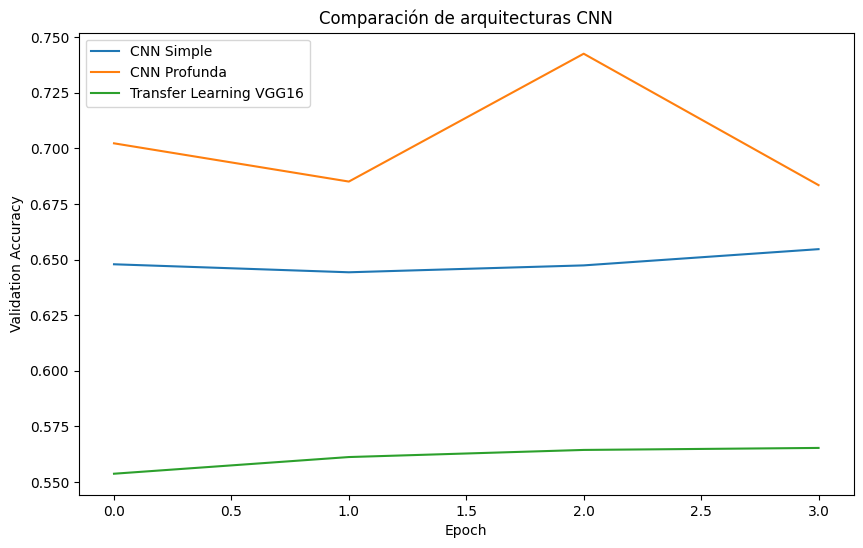

In [12]:
# Puedes tomar como base el código visto en clase para generar las graficos de comparación de las arquitecturas o puedes proptear tu propia forma de visualización.
def plot_accuracy(histories, labels):

    plt.figure(figsize=(10,6))

    for history, label in zip(histories, labels):
        plt.plot(history.history['val_accuracy'], label=label)

    plt.title("Comparación de arquitecturas CNN")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.legend()
    plt.show()

plot_accuracy(
    [history1, history2, history3],
    ["CNN Simple", "CNN Profunda", "Transfer Learning VGG16"]
)

# Conclusiones.

Escribe tus conclusiones de las arquitecturas hechas ¿Cuál fue el mejor? ¿Por qué? ¿Qué mejoraría? ¿Cómo lo mejoraría?

## Conclusiones

En esta práctica se implementaron tres arquitecturas distintas para la clasificación del dataset CIFAR-10: dos arquitecturas CNN diseñadas manualmente y un modelo basado en transfer learning utilizando VGG16.

El rendimiento de las arquitecturas muestra que la CNN profunda logra el mejor desempeño, alcanzando aproximadamente 74% de accuracy en validación.

La CNN simple tiene un desempeño aceptable pero inferior debido a su menor capacidad para capturar características complejas de las imágenes.

El modelo de transfer learning basado en VGG16 obtuvo el rendimiento más bajo, lo cual puede atribuirse a la diferencia entre el tamaño de las imágenes de CIFAR-10 y las imágenes utilizadas durante el entrenamiento original de VGG16 en ImageNet.

En general, el rendimiento de los modelos podría mejorar mediante un mayor número de épocas de entrenamiento, un ajuste más cuidadoso de los hiperparámetros, arquitecturas más profundas y un uso más avanzado de técnicas de data augmentation y transfer learning. Estas estrategias permitirían mejorar la capacidad del modelo para extraer características relevantes y aumentar la precisión en la clasificación de imágenes.